# Pre-Merger Diagnostics

This notebook is for pre-merger diagnostic checks before the main DiD analysis.

## Diagnostic Overview

This notebook investigates whether pre-treatment differences across hospitals could undermine causal interpretation in the merger analysis. It focuses on pre-merger levels and trends for treated hospitals versus never-treated controls before running the final DiD specification.

## Staggered Treatment Context

Hospitals enter treatment in different calendar years, so pre-trend diagnostics are evaluated relative to each treated hospital's own merger timing. We use years_to_merger and fiscal-year views together to detect whether trend differences are broad or cohort-specific.

## Objectives

- Build a clean pre-treatment diagnostic sample
- Compare treated pre-merger hospitals to never-treated hospitals on baseline covariates
- Visualize pre-merger trend patterns by merger cohort
- Identify abnormal cohorts that may drive violations
- Re-run diagnostics after excluding suspicious cohorts (especially 2017)

## Dataset Description

Input data come from ../01_data/hospital_analysis.csv at the hospital-year level. Core fields include PRVDR_NUM, fiscal_year, treated, merger_year, years_to_merger, cost_per_discharge, and operational size controls.

## Expected Outcome

By the end of this notebook, you should have a clear diagnostic read on where pre-trend concerns come from, whether they are cohort-concentrated, and whether excluding problematic cohorts improves identification credibility.

## Step 1 - Load and Prepare Diagnostic Dataset

This step loads the main hospital panel and keeps only the variables needed to diagnose why pre-treatment trends may differ across hospitals.

In [ ]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATA_PATH = "../01_data/hospital_analysis.csv"
keep_cols = [
    "PRVDR_NUM",
    "fiscal_year",
    "treated",
    "merger_year",
    "years_to_merger",
    "cost_per_discharge",
    "total_operating_costs",
    "total_discharges",
    "PRVDR_CTRL_TYPE_CD",
    "hrrcode",
    "fac_name",
]
numeric_cols = [
    "fiscal_year",
    "treated",
    "merger_year",
    "years_to_merger",
    "cost_per_discharge",
    "total_operating_costs",
    "total_discharges",
]

diagnostic_df = pd.read_csv(DATA_PATH, usecols=keep_cols).copy()
diagnostic_df[numeric_cols] = diagnostic_df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)
diagnostic_df["PRVDR_NUM"] = diagnostic_df["PRVDR_NUM"].astype(str).str.strip()
diagnostic_df = diagnostic_df.dropna(subset=["PRVDR_NUM", "fiscal_year", "treated"])
diagnostic_df = diagnostic_df[diagnostic_df["treated"].isin([0, 1])].copy()

In [2]:
hospital_treat_status = diagnostic_df.groupby("PRVDR_NUM", as_index=False)[
    "treated"
].max()
n_treated_hospitals = int((hospital_treat_status["treated"] == 1).sum())
n_never_treated_hospitals = int((hospital_treat_status["treated"] == 0).sum())

print("Dataset shape:", diagnostic_df.shape)
print("Unique hospitals:", diagnostic_df["PRVDR_NUM"].nunique())
print(
    "Fiscal year range:",
    int(diagnostic_df["fiscal_year"].min()),
    "to",
    int(diagnostic_df["fiscal_year"].max()),
)
print("Treated hospitals:", n_treated_hospitals)
print("Never-treated hospitals:", n_never_treated_hospitals)

diagnostic_df.head()

Dataset shape: (55805, 11)
Unique hospitals: 6710
Fiscal year range: 2011 to 2019
Treated hospitals: 1242
Never-treated hospitals: 5468


,fiscal_year,PRVDR_NUM,PRVDR_CTRL_TYPE_CD,total_operating_costs,total_discharges,cost_per_discharge,fac_name,hrrcode,merger_year,treated,years_to_merger
0,2011,271326,2,8661723.0,155.0,55882.083871,BEARTOOTH BILLINGS CLINIC,274.0,NaN,0,NaN
1,2011,13025,4,39554420.0,2390.0,16549.966527,NaN,NaN,NaN,0,NaN
2,2011,103037,4,20242022.0,1370.0,14775.198540,NaN,NaN,NaN,0,NaN
3,2011,103042,4,26136744.0,1495.0,17482.771906,NaN,NaN,NaN,0,NaN
4,2011,141990,1,116445.0,11.0,10585.909091,NaN,NaN,NaN,0,NaN


## Step 2 - Define Treated Hospitals and Build Pre-Merger Sample

This step isolates hospitals that eventually merge and keeps only their pre-merger observations so we can study how they behave before treatment.

In [ ]:
hospital_treat_status = diagnostic_df.groupby("PRVDR_NUM", as_index=False)[
    "treated"
].max()
treated_hospital_ids = set(
    hospital_treat_status.loc[hospital_treat_status["treated"] == 1, "PRVDR_NUM"]
)
never_treated_sample = diagnostic_df[diagnostic_df["treated"] == 0].copy()

treated_merger_year = (
    diagnostic_df[
        diagnostic_df["PRVDR_NUM"].isin(treated_hospital_ids)
        & diagnostic_df["merger_year"].notna()
    ]
    .groupby("PRVDR_NUM", as_index=False)["merger_year"]
    .min()
    .rename(columns={"merger_year": "first_merger_year"})
)
treated_merger_year["first_merger_year"] = treated_merger_year[
    "first_merger_year"
].astype(int)

treated_pre_merger_sample = diagnostic_df[
    diagnostic_df["PRVDR_NUM"].isin(treated_merger_year["PRVDR_NUM"])
    & diagnostic_df["years_to_merger"].notna()
    & (diagnostic_df["years_to_merger"] < 0)
].copy()

print(
    "Treated hospitals with valid first merger year:",
    treated_merger_year["PRVDR_NUM"].nunique(),
)
print("Treated pre-merger sample shape:", treated_pre_merger_sample.shape)
print("Never-treated sample shape:", never_treated_sample.shape)
print(
    "Treated pre-merger years_to_merger range:",
    (
        float(treated_pre_merger_sample["years_to_merger"].min())
        if not treated_pre_merger_sample.empty
        else np.nan
    ),
    "to",
    (
        float(treated_pre_merger_sample["years_to_merger"].max())
        if not treated_pre_merger_sample.empty
        else np.nan
    ),
)

display(treated_merger_year.head())
display(treated_pre_merger_sample.head())

Treated hospitals with valid first merger year: 1242
Treated pre-merger sample shape: (4757, 11)
Never-treated sample shape: (44469, 11)
Treated pre-merger years_to_merger range: -8.0 to -1.0


,PRVDR_NUM,first_merger_year
0,100002,2017
1,100014,2016
2,100023,2014
3,100026,2012
4,100030,2012


,fiscal_year,PRVDR_NUM,PRVDR_CTRL_TYPE_CD,total_operating_costs,total_discharges,cost_per_discharge,fac_name,hrrcode,merger_year,treated,years_to_merger
22,2011,111314,4,17766713.0,283.0,62779.904594,PIONEER COMMUNITY HOSPITAL OF EARLY,2.0,2017.0,1,-6.0
26,2011,10146,4,26187949.0,1954.0,13402.225691,JACKSONVILLE MEDICAL CENTER,1.0,2012.0,1,-1.0
27,2011,10169,2,16328100.0,1255.0,13010.438247,ATMORE COMMUNITY HOSPITAL,134.0,2015.0,1,-4.0
42,2011,521317,2,20371432.0,482.0,42264.381743,CALUMET MEDICAL CTR,446.0,2013.0,1,-2.0
46,2011,381303,1,43543853.0,925.0,47074.435676,PROVIDENCE SEASIDE HOSPITAL,344.0,2016.0,1,-5.0


## Step 3 - Baseline Comparison: Treated Pre-Merger vs Never-Treated

This step checks whether hospitals that eventually merge already look different from never-treated hospitals before the merger happens.

In [ ]:
def modal_value(s):
    m = s.dropna().mode()
    return m.iloc[0] if not m.empty else np.nan


treated_hospital_summary = treated_pre_merger_sample.groupby(
    "PRVDR_NUM", as_index=False
).agg(
    cost_per_discharge=("cost_per_discharge", "mean"),
    total_operating_costs=("total_operating_costs", "mean"),
    total_discharges=("total_discharges", "mean"),
    PRVDR_CTRL_TYPE_CD=("PRVDR_CTRL_TYPE_CD", modal_value),
    hrrcode=("hrrcode", modal_value),
)
treated_hospital_summary["group"] = "treated_pre_merger"

never_treated_hospital_summary = never_treated_sample.groupby(
    "PRVDR_NUM", as_index=False
).agg(
    cost_per_discharge=("cost_per_discharge", "mean"),
    total_operating_costs=("total_operating_costs", "mean"),
    total_discharges=("total_discharges", "mean"),
    PRVDR_CTRL_TYPE_CD=("PRVDR_CTRL_TYPE_CD", modal_value),
    hrrcode=("hrrcode", modal_value),
)
never_treated_hospital_summary["group"] = "never_treated"

comparison_df = pd.concat(
    [treated_hospital_summary, never_treated_hospital_summary], ignore_index=True
)

pd.DataFrame(
    {
        "group": ["treated_pre_merger", "never_treated"],
        "n_hospitals": [
            treated_hospital_summary["PRVDR_NUM"].nunique(),
            never_treated_hospital_summary["PRVDR_NUM"].nunique(),
        ],
    }
)

,group,n_hospitals
0,treated_pre_merger,1135
1,never_treated,5468


In [14]:
continuous_vars = ["cost_per_discharge", "total_operating_costs", "total_discharges"]

continuous_summary = pd.DataFrame(
    [
        {
            "variable": v,
            "treated_mean": treated_hospital_summary[v].mean(),
            "treated_median": treated_hospital_summary[v].median(),
            "never_treated_mean": never_treated_hospital_summary[v].mean(),
            "never_treated_median": never_treated_hospital_summary[v].median(),
        }
        for v in continuous_vars
    ]
)

continuous_summary

,variable,treated_mean,treated_median,never_treated_mean,never_treated_median
0,cost_per_discharge,3.912750e+04,2.234282e+04,9.454270e+04,2.965843e+04
1,total_operating_costs,1.599206e+08,9.011723e+07,1.380312e+08,3.349985e+07
2,total_discharges,7.338572e+03,4.502500e+03,4.815840e+03,1.225111e+03


In [15]:
ownership_distribution = (
    comparison_df.assign(
        PRVDR_CTRL_TYPE_CD=comparison_df["PRVDR_CTRL_TYPE_CD"].astype(str)
    )
    .groupby(["group", "PRVDR_CTRL_TYPE_CD"], as_index=False)
    .size()
    .rename(columns={"size": "n_hospitals"})
)
ownership_distribution["share"] = ownership_distribution[
    "n_hospitals"
] / ownership_distribution.groupby("group")["n_hospitals"].transform("sum")

ownership_distribution.sort_values(["group", "n_hospitals"], ascending=[True, False])

,group,PRVDR_CTRL_TYPE_CD,n_hospitals,share
5,never_treated,2,1994,0.364667
7,never_treated,4,1493,0.273043
0,never_treated,1,391,0.071507
12,never_treated,9,371,0.067849
2,never_treated,11,336,0.061448
1,never_treated,10,266,0.048647
8,never_treated,5,232,0.042429
9,never_treated,6,112,0.020483
11,never_treated,8,79,0.014448
4,never_treated,13,66,0.012070


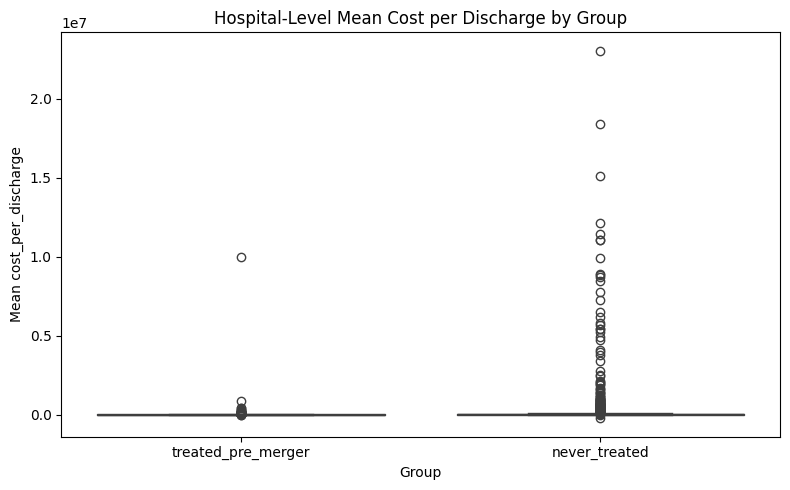

In [16]:
plot_df = comparison_df[["group", "cost_per_discharge"]].dropna().copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x="group", y="cost_per_discharge")
plt.title("Hospital-Level Mean Cost per Discharge by Group")
plt.xlabel("Group")
plt.ylabel("Mean cost_per_discharge")
plt.tight_layout()
plt.show()

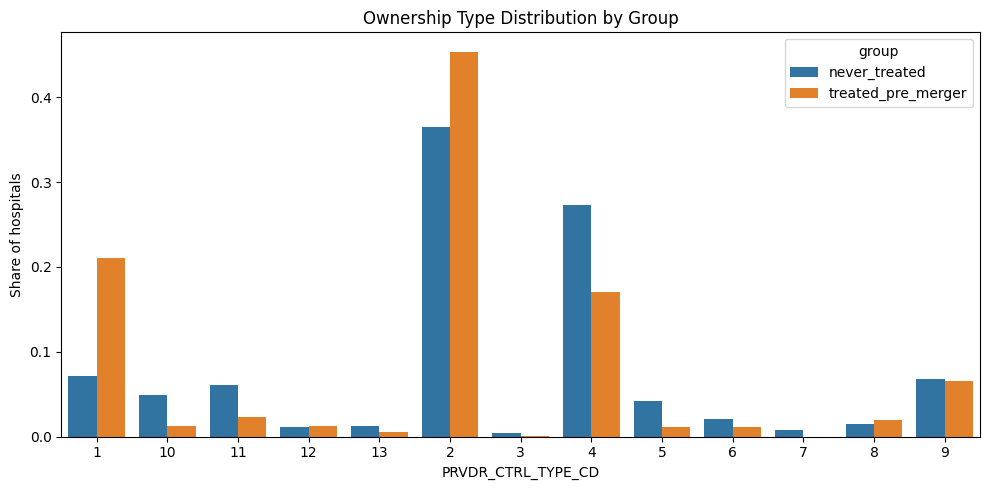

In [17]:
ownership_plot = (
    comparison_df.assign(
        PRVDR_CTRL_TYPE_CD=comparison_df["PRVDR_CTRL_TYPE_CD"].astype(str)
    )
    .groupby(["group", "PRVDR_CTRL_TYPE_CD"], as_index=False)
    .size()
    .rename(columns={"size": "n_hospitals"})
)
ownership_plot["share"] = ownership_plot["n_hospitals"] / ownership_plot.groupby(
    "group"
)["n_hospitals"].transform("sum")

plt.figure(figsize=(10, 5))
sns.barplot(data=ownership_plot, x="PRVDR_CTRL_TYPE_CD", y="share", hue="group")
plt.title("Ownership Type Distribution by Group")
plt.xlabel("PRVDR_CTRL_TYPE_CD")
plt.ylabel("Share of hospitals")
plt.tight_layout()
plt.show()

### Key Insight: Pre-Merger Differences Between Treated and Control Hospitals

In this step, we compared hospitals that eventually merge (treated) with those that never merge (control) using only pre-merger data.

The results show that treated hospitals are systematically different from never-treated hospitals even before the merger occurs:

- Treated hospitals tend to be larger (higher total discharges and operating costs).
- There are noticeable differences in ownership structure across groups.
- The distribution of cost per discharge is highly skewed, but medians suggest differences in underlying cost structure.
  
These findings indicate the presence of **selection bias**:
hospitals that merge are not randomly selected, but already differ from others before treatment.

This helps explain why the **parallel trends assumption failed** in earlier Difference-in-Differences analysis.

Implication:
A simple DiD approach may not yield valid causal estimates without further adjustments (e.g., matching, fixed effects, or sample restrictions).

## Step 4 - Pre-Merger Trends by Merger Cohort

We are checking whether specific merger cohorts drive the non-parallel pre-trends observed earlier.

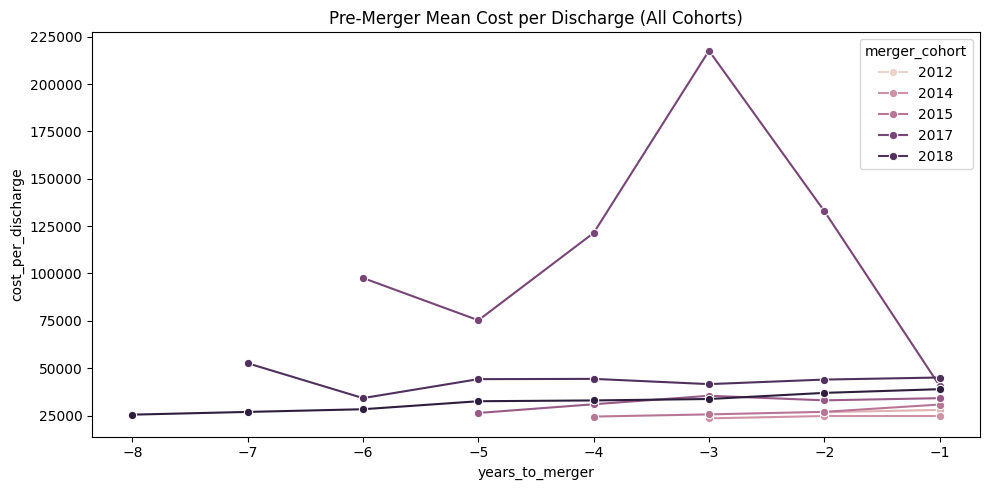

In [20]:
treated_pre_with_cohort = treated_pre_merger_sample.merge(
    treated_merger_year.rename(columns={"first_merger_year": "merger_cohort"}),
    on="PRVDR_NUM",
    how="left",
)
treated_pre_with_cohort = treated_pre_with_cohort[
    treated_pre_with_cohort["merger_cohort"].notna()
].copy()
treated_pre_with_cohort["merger_cohort"] = treated_pre_with_cohort[
    "merger_cohort"
].astype(int)

cohort_trend_table = (
    treated_pre_with_cohort.groupby(
        ["years_to_merger", "merger_cohort"], as_index=False
    )["cost_per_discharge"]
    .mean()
    .sort_values(["merger_cohort", "years_to_merger"])
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cohort_trend_table,
    x="years_to_merger",
    y="cost_per_discharge",
    hue="merger_cohort",
    marker="o",
)
plt.title("Pre-Merger Mean Cost per Discharge (All Cohorts)")
plt.tight_layout()
plt.show()

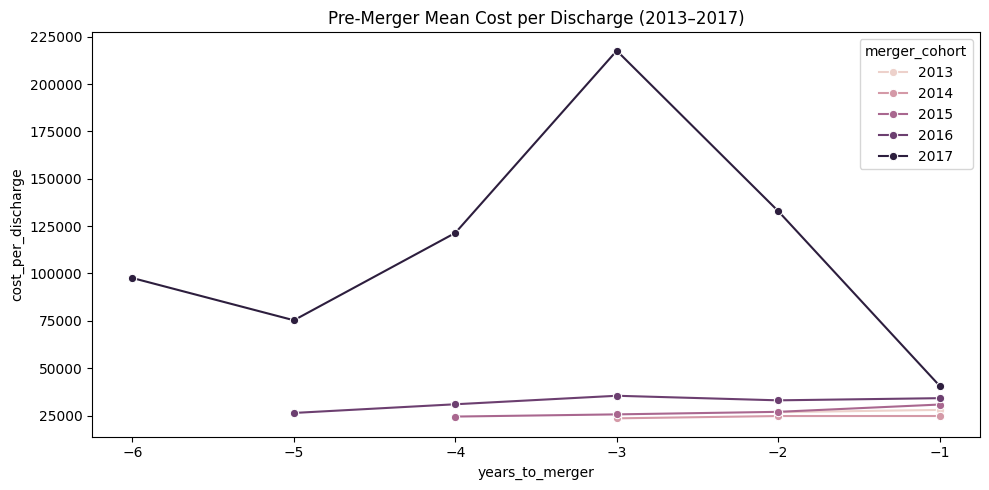

In [21]:
focus_cohorts = [2013, 2014, 2015, 2016, 2017]
cohort_trend_focus = cohort_trend_table[
    cohort_trend_table["merger_cohort"].isin(focus_cohorts)
]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cohort_trend_focus,
    x="years_to_merger",
    y="cost_per_discharge",
    hue="merger_cohort",
    marker="o",
)
plt.title("Pre-Merger Mean Cost per Discharge (2013–2017)")
plt.tight_layout()
plt.show()

In [22]:
cohort_change = cohort_trend_table.sort_values(
    ["merger_cohort", "years_to_merger"]
).copy()
cohort_change["delta"] = cohort_change.groupby("merger_cohort")[
    "cost_per_discharge"
].diff()

threshold = cohort_change["delta"].abs().quantile(0.90)
flagged = cohort_change[cohort_change["delta"].abs() >= threshold]

flagged[["merger_cohort", "years_to_merger", "cost_per_discharge", "delta"]]

,merger_cohort,years_to_merger,cost_per_discharge,delta
18,2017,-3.0,217583.698216,96188.151726
25,2017,-2.0,132911.512943,-84672.185273
33,2017,-1.0,40667.858805,-92243.654139


/Users/far/miniforge3/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


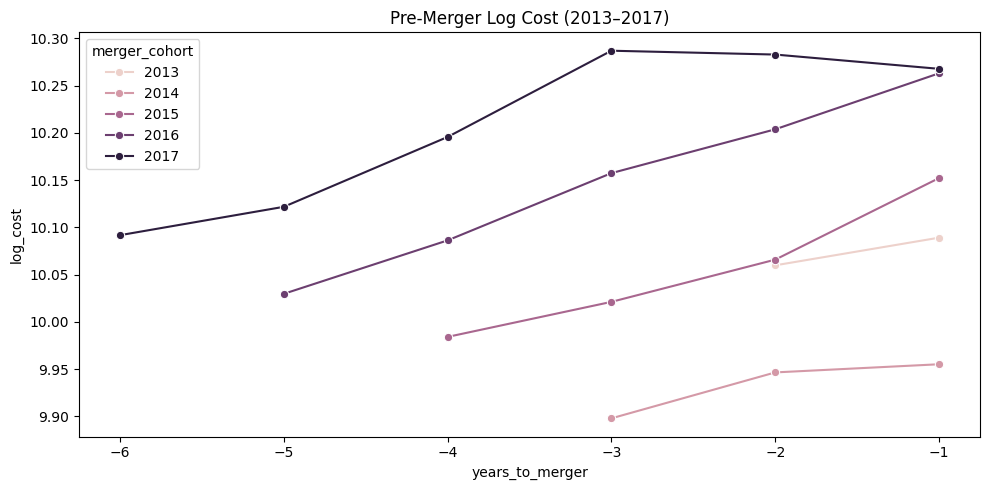

In [23]:
cohort_log = (
    treated_pre_with_cohort.assign(
        log_cost=np.log1p(treated_pre_with_cohort["cost_per_discharge"])
    )
    .groupby(["years_to_merger", "merger_cohort"], as_index=False)["log_cost"]
    .mean()
)

cohort_log_focus = cohort_log[cohort_log["merger_cohort"].isin(focus_cohorts)]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cohort_log_focus,
    x="years_to_merger",
    y="log_cost",
    hue="merger_cohort",
    marker="o",
)
plt.title("Pre-Merger Log Cost (2013–2017)")
plt.tight_layout()
plt.show()

### Key Insight: Cohort-Specific Pre-Trend Differences

In this step, we examined pre-merger trends separately by merger cohort to identify the source of non-parallel trends observed earlier.

The results show that:
- Most cohorts (especially 2013–2016) exhibit relatively smooth and similar pre-merger trends.
- However, the 2017 cohort shows large and irregular fluctuations, including sharp increases and decreases in cost per discharge prior to merger.
- These patterns persist even after log transformation, suggesting that the issue is not driven solely by outliers in scale.

This indicates that the violation of the parallel trends assumption is primarily driven by specific cohorts (notably 2017), rather than being a general issue across all treated hospitals.

### Implication

We have successfully identified a likely source of the non-parallel trends problem: a subset of cohorts with abnormal pre-treatment dynamics.

At this stage, further diagnostic steps are not strictly necessary to identify the issue. Instead, the next step is to adjust the research design, for example by:
- restricting the sample to more stable cohorts (e.g., 2015–2016), or
- excluding problematic cohorts (e.g., 2017)

This allows for a more credible Difference-in-Differences analysis moving forward.

## Step 5 - Remove Problematic Cohort (2017) and Re-Run Trend Diagnostics

Because cohort 2017 shows abnormal pre-treatment dynamics, we remove it and re-run cohort-based pre-trend diagnostics to check whether pre-trend behavior is more stable in the remaining treated cohorts.

In [27]:
treated_hospitals_before = treated_merger_year["PRVDR_NUM"].nunique()

treated_merger_year_no2017 = treated_merger_year[
    treated_merger_year["first_merger_year"] != 2017
].copy()
treated_hospitals_after = treated_merger_year_no2017["PRVDR_NUM"].nunique()

treated_ids_no2017 = set(treated_merger_year_no2017["PRVDR_NUM"])

treated_pre_merger_sample_no2017 = treated_pre_merger_sample[
    treated_pre_merger_sample["PRVDR_NUM"].isin(treated_ids_no2017)
].copy()

treated_pre_with_cohort_no2017 = treated_pre_merger_sample_no2017.merge(
    treated_merger_year_no2017.rename(columns={"first_merger_year": "merger_cohort"}),
    on="PRVDR_NUM",
    how="left",
)

treated_pre_with_cohort_no2017 = treated_pre_with_cohort_no2017[
    treated_pre_with_cohort_no2017["merger_cohort"].notna()
].copy()

treated_pre_with_cohort_no2017["merger_cohort"] = treated_pre_with_cohort_no2017[
    "merger_cohort"
].astype(int)

remaining_cohorts = sorted(treated_merger_year_no2017["first_merger_year"].unique())

print("Before:", treated_hospitals_before)
print("After:", treated_hospitals_after)
print("Remaining cohorts:", remaining_cohorts)

Before: 1242
After: 1137
Remaining cohorts: [2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019]


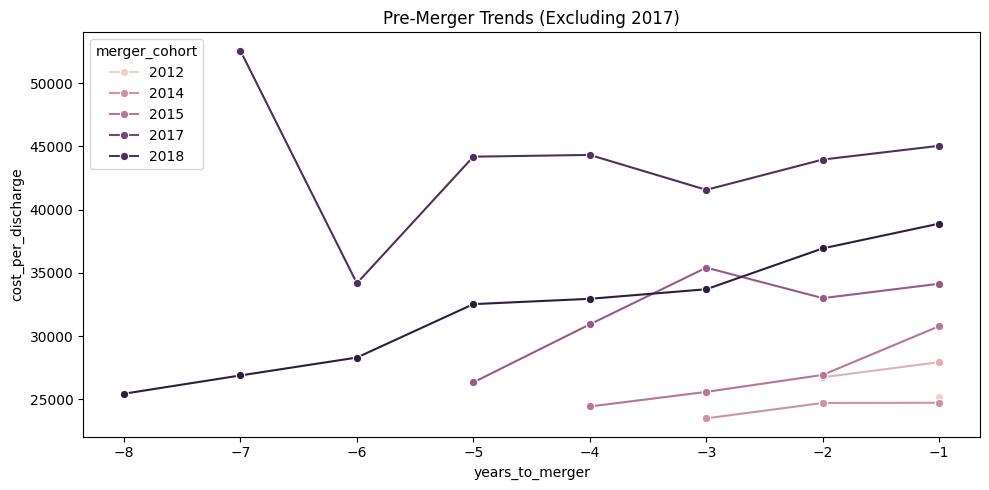

In [28]:
cohort_trend_table_no2017 = (
    treated_pre_with_cohort_no2017.groupby(
        ["years_to_merger", "merger_cohort"], as_index=False
    )["cost_per_discharge"]
    .mean()
    .sort_values(["merger_cohort", "years_to_merger"])
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cohort_trend_table_no2017,
    x="years_to_merger",
    y="cost_per_discharge",
    hue="merger_cohort",
    marker="o",
)
plt.title("Pre-Merger Trends (Excluding 2017)")
plt.tight_layout()
plt.show()

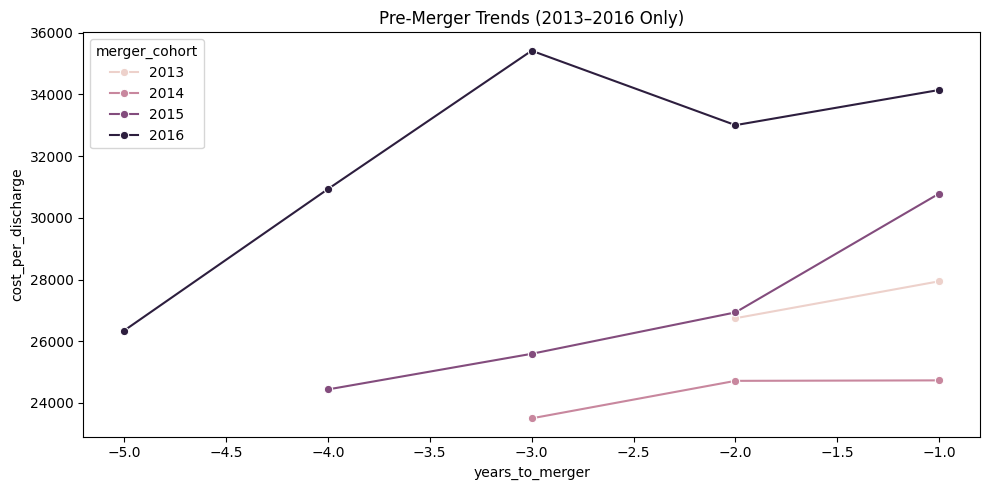

In [29]:
focus_cohorts = [2013, 2014, 2015, 2016]

cohort_trend_focus_no2017 = cohort_trend_table_no2017[
    cohort_trend_table_no2017["merger_cohort"].isin(focus_cohorts)
]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=cohort_trend_focus_no2017,
    x="years_to_merger",
    y="cost_per_discharge",
    hue="merger_cohort",
    marker="o",
)
plt.title("Pre-Merger Trends (2013–2016 Only)")
plt.tight_layout()
plt.show()

## Step 6 - Re-Run Parallel Trends Test After Removing Cohort 2017

We are testing whether removing the problematic cohort (2017) improves the validity of the parallel trends assumption.

In [31]:
analysis_df = diagnostic_df[
    (diagnostic_df["PRVDR_NUM"].isin(treated_ids_no2017))
    | (diagnostic_df["treated"] == 0)
].copy()

analysis_df["log_cost_per_discharge"] = np.where(
    analysis_df["cost_per_discharge"] > -1,
    np.log1p(analysis_df["cost_per_discharge"]),
    np.nan,
)

analysis_df = analysis_df.dropna(
    subset=["log_cost_per_discharge", "treated", "fiscal_year"]
).copy()
analysis_df["fiscal_year"] = analysis_df["fiscal_year"].astype(int)
analysis_df["treated"] = analysis_df["treated"].astype(int)

print("Shape:", analysis_df.shape)
print(
    "Treated hospitals:",
    analysis_df.loc[analysis_df["treated"] == 1, "PRVDR_NUM"].nunique(),
)
print(
    "Control hospitals:",
    analysis_df.loc[analysis_df["treated"] == 0, "PRVDR_NUM"].nunique(),
)

Shape: (52390, 12)
Treated hospitals: 1137
Control hospitals: 5219


/Users/far/miniforge3/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


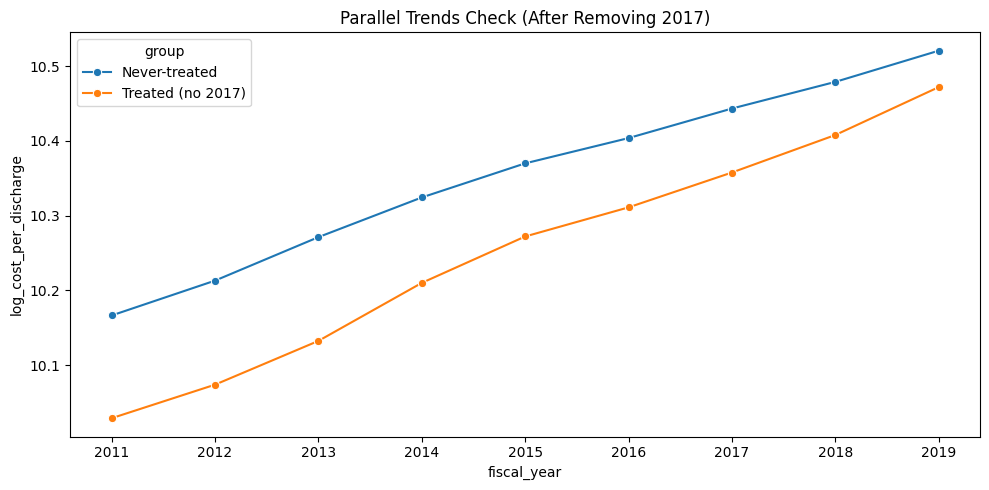

In [32]:
trend_check = analysis_df.groupby(["fiscal_year", "treated"], as_index=False)[
    "log_cost_per_discharge"
].mean()
trend_check["group"] = trend_check["treated"].map(
    {0: "Never-treated", 1: "Treated (no 2017)"}
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=trend_check,
    x="fiscal_year",
    y="log_cost_per_discharge",
    hue="group",
    marker="o",
)
plt.title("Parallel Trends Check (After Removing 2017)")
plt.tight_layout()
plt.show()

In [33]:
pt_model = smf.ols(
    "log_cost_per_discharge ~ treated + C(fiscal_year) + treated:C(fiscal_year)",
    data=analysis_df,
).fit(cov_type="HC1")

interaction_terms = [
    x for x in pt_model.params.index if x.startswith("treated:C(fiscal_year)")
]

if not interaction_terms:
    p_val = np.nan
    print("No interaction terms.")
else:
    hypothesis = " , ".join([f"{x} = 0" for x in interaction_terms])
    f_test = pt_model.f_test(hypothesis)
    p_val = float(np.asarray(f_test.pvalue).squeeze())
    print(f"p-value = {p_val:.4g}")

print("\nConclusion:")
if np.isnan(p_val):
    print("Unable to conclude")
elif p_val < 0.05:
    print("Reject parallel trends")
else:
    print("No evidence against parallel trends")

p-value = 0.03167

Conclusion:
Reject parallel trends
